In [1]:
import pandas as pd
import numpy as np

In [2]:
data=pd.read_csv('AirPassengers.csv')

In [3]:
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
data['Month']=pd.to_datetime(data['Month'])

In [5]:
data.set_index('Month',inplace=True)

In [6]:
data.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [7]:
y=data.iloc[:,-1]

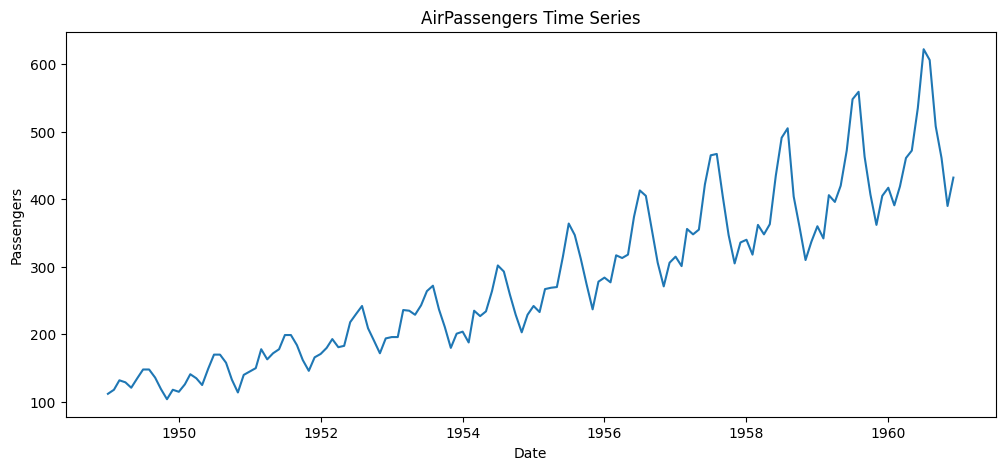

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(y)

plt.title("AirPassengers Time Series")
plt.xlabel("Date")
plt.ylabel("Passengers")

plt.show()

In [9]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [10]:
train=y[:-24]
test=y[-24:]

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates

<Figure size 640x480 with 0 Axes>

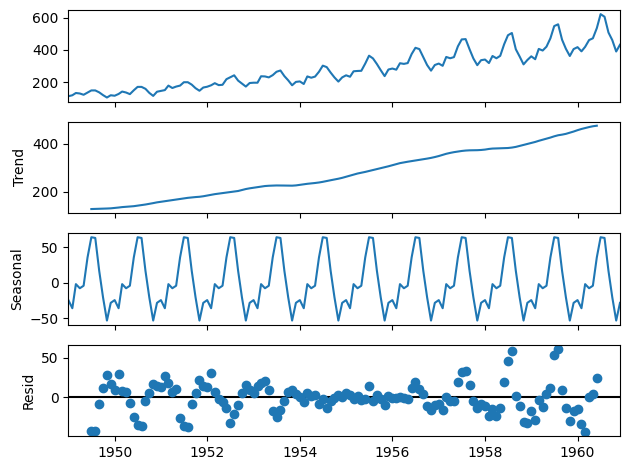

In [19]:
results=seasonal_decompose(data,model='additive',period=12)
for ax in plt.gcf().axes:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x',labelrotation=45)
results.plot()
plt.tight_layout()
plt.show()

In [32]:
ets_model = ExponentialSmoothing(
    train,
    trend="mul",
    seasonal="mul",
    seasonal_periods=12
)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [33]:
ets_result = ets_model.fit()

In [34]:
ets_result.params

{'smoothing_level': np.float64(0.3796477993954173),
 'smoothing_trend': np.float64(0.0),
 'smoothing_seasonal': np.float64(0.6203522006045827),
 'damping_trend': nan,
 'initial_level': np.float64(124.67272744794104),
 'initial_trend': np.float64(1.009630838822145),
 'initial_seasons': array([0.88978883, 0.93807788, 1.03491528, 0.98242561, 0.9043626 ,
        0.99607471, 1.09127563, 1.079233  , 0.98209524, 0.85134316,
        0.7536027 , 0.87771179]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [35]:
forecast=ets_result.forecast(len(test))

In [36]:
forecast.index=test.index

In [37]:
forecast

Month
1959-01-01    353.807428
1959-02-01    337.555686
1959-03-01    393.806085
1959-04-01    387.476236
1959-05-01    407.013635
1959-06-01    487.824142
1959-07-01    545.610787
1959-08-01    550.129162
1959-09-01    446.734833
1959-10-01    395.511005
1959-11-01    343.289999
1959-12-01    386.375371
1960-01-01    396.933941
1960-02-01    378.701232
1960-03-01    441.808139
1960-04-01    434.706728
1960-05-01    456.625592
1960-06-01    547.286302
1960-07-01    612.116714
1960-08-01    617.185845
1960-09-01    501.188510
1960-10-01    443.720877
1960-11-01    385.134515
1960-12-01    433.471676
dtype: float64

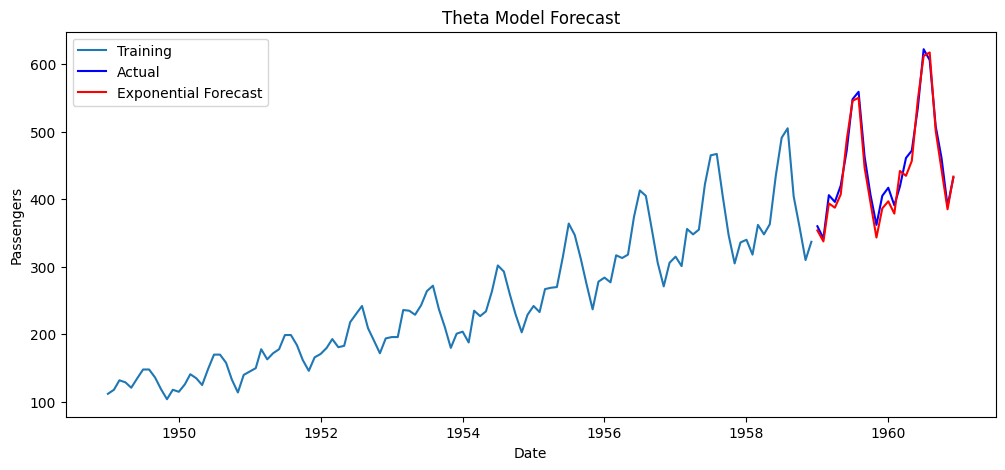

In [38]:
plt.figure(figsize=(12, 5))

plt.plot(train, label="Training")
plt.plot(test, label="Actual", color="blue")
plt.plot(forecast, label="Exponential Forecast", color="red")

plt.title("Theta Model Forecast")
plt.xlabel("Date")
plt.ylabel("Passengers")

plt.legend()
plt.show()

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

mape = np.mean(
    np.abs((test - forecast) / test)
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

MAE : 12.380740286587333
RMSE: 13.87860158270763
MAPE: 2.813181999999115 %


In [40]:
# # 5. Why is it called "exponential"?

# # Because the weights assigned to older observations decrease approximately exponentially.

# # Conceptually:

# # Recent observation→high weight
# # Older observation→lower weight
# # Very old observation→very small weight
# α=level smoothing
# β=trend smoothing
# γ=seasonal smoothing

In [41]:
data=data.asfreq('MS')

In [42]:
ets_model = ExponentialSmoothing(
    data,
    trend="mul",
    seasonal="mul",
    seasonal_periods=12
)

In [43]:
ets_result=ets_model.fit()

In [44]:
future_forecast=ets_result.forecast(12)

In [45]:
future_forecast

1961-01-01    450.676812
1961-02-01    424.820363
1961-03-01    475.499131
1961-04-01    504.076124
1961-05-01    517.873474
1961-06-01    590.148588
1961-07-01    684.228907
1961-08-01    678.033373
1961-09-01    567.112765
1961-10-01    507.823702
1961-11-01    434.719922
1961-12-01    485.981647
Freq: MS, dtype: float64

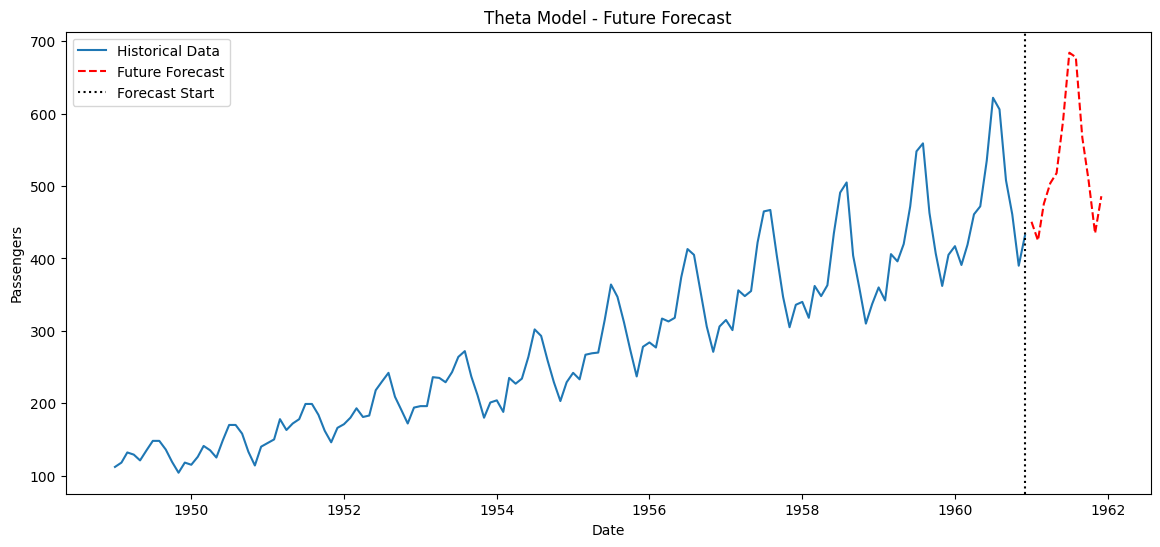

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    y,
    label="Historical Data"
)

plt.plot(
    future_forecast,
    label="Future Forecast",
    color="red",
    linestyle="--"
)

plt.axvline(
    y.index[-1],
    color="black",
    linestyle=":",
    label="Forecast Start"
)

plt.title("Theta Model - Future Forecast")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()

plt.show()

In [29]:
configs = [
    ("add", "add"),
    ("add", "mul"),
    ("mul", "add"),
    ("mul", "mul")
]

In [31]:
for trend, seasonal in configs:

    try:
        model = ExponentialSmoothing(
            train,
            trend=trend,
            seasonal=seasonal,
            seasonal_periods=12,
            damped_trend=True
        )

        fitted = model.fit(optimized=True)

        pred = fitted.forecast(len(test))

        rmse = np.sqrt(
            mean_squared_error(test, pred)
        )

        print(
            trend,
            seasonal,
            "RMSE:", rmse
        )

    except Exception as e:
        print(trend, seasonal, "failed:", e)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


add add RMSE: 46.61727023265975


C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


add mul RMSE: 40.996809586829


C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


mul add RMSE: 15.580472441746343


C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


mul mul RMSE: 12.914477902814381


In [ ]:
periods=[6,8,9,11,12,24,48]
for period in periods:
    for trend, seasonal in configs:
        try:
            model=ExponentialSmoothing(train,trend=trend,seasonal=seasonal,seasonal_periods=period,damped=True)
            fitted=model.fit(optimized=True)
            pred=fitted.forecast(len(test))
            rmse=np.sqrt(mean_squared_error(test,pred))
            print("period:",period,"trend:",trend,"seasonal:",seasonal,"RMSE:",rmse)
        except Exception as e:
            print(trend, seasonal, "failed:", e)

C:\Users\Mcc\AppData\Local\Temp\ipykernel_12952\1639807812.py:5: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  model=ExponentialSmoothing(train,trend=trend,seasonal=seasonal,seasonal_periods=period,damped=True)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


period: 6 trend: add seasonal: add RMSE: 123.53673200966246


C:\Users\Mcc\AppData\Local\Temp\ipykernel_12952\1639807812.py:5: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  model=ExponentialSmoothing(train,trend=trend,seasonal=seasonal,seasonal_periods=period,damped=True)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


period: 6 trend: add seasonal: mul RMSE: 136.66478199150302


C:\Users\Mcc\AppData\Local\Temp\ipykernel_12952\1639807812.py:5: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  model=ExponentialSmoothing(train,trend=trend,seasonal=seasonal,seasonal_periods=period,damped=True)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


...

period: 24 trend: mul seasonal: mul RMSE: 28.17682808618641


C:\Users\Mcc\AppData\Local\Temp\ipykernel_12952\1639807812.py:5: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  model=ExponentialSmoothing(train,trend=trend,seasonal=seasonal,seasonal_periods=period,damped=True)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\Mcc\AppData\Local\Temp\ipykernel_12952\1639807812.py:5: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  model=ExponentialSmoothing(train,trend=trend,seasonal=seasonal,seasonal_periods=period,damped=True)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:

period: 48 trend: add seasonal: add RMSE: 99.86948735608337


C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\Mcc\AppData\Local\Temp\ipykernel_12952\1639807812.py:5: FutureWarning: the 'damped' keyword is deprecated, use 'damped_trend' instead.
  model=ExponentialSmoothing(train,trend=trend,seasonal=seasonal,seasonal_periods=period,damped=True)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


period: 48 trend: add seasonal: mul RMSE: 51.02677552022862
